**SINGLE NEURON FUNDAMENTALS**

**FORWARD PASS**

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [157]:
datapoint = np.array([0.05,0.37,0.46])
weights = np.array([0.4,0.2,0.1])
bias = 0.6769

In [158]:
z = np.dot(datapoint,weights) + bias
z

np.float64(0.8169)

In [159]:
sigmoid = 1 / (1 + np.exp(-z)) #Activation function
print(sigmoid)

0.6935779002102053


In [160]:
weights = np.array([[0.4, 0.2, 0.1],[0.1, 0.5, 0.3],[0.2, 0.2, 0.6],[0.7, 0.1, 0.1]])

In [161]:
bias = np.array([0.67 , 0.69 , 0.66 , 0.68])

In [162]:
z = np.dot(weights,datapoint) + bias
print(z)

[0.81  1.018 1.02  0.798]


In [163]:
print(z.shape)

(4,)


In [164]:
a1 = 1 / (1 + np.exp(-z))
a1

array([0.6921095 , 0.73458284, 0.7349726 , 0.6895465 ])

In [165]:
w2 = np.array([[0.3,0.5,0.7,0.1],[0.2,0.5,0.6,0.3]])
b2 = np.array([0.5,0.9])
z2 = np.dot(w2,a1) + b2
print(z2.shape)
a2 = 1 / (1 + np.exp(-z2))
print(a2.shape)
print(a2)

(2,)
(2,)
[0.84001769 0.88630693]


**BACKPROPAGATION AND LOSS FUNCTION**

In [166]:
y = [1,0]

In [167]:
#binary_Cross_entropy_loss = (-y * log(p) + (1-y) * log)

In [168]:
loss1 = -(y[0] * np.log(a2[0]) + (1-y[0]) * np.log(1-a2[0]))
print(loss1)
loss2 = -(y[1] * np.log(a2[1]) + (1-y[1]) * np.log(1-a2[1]))
print(loss2)
total_loss = loss1 + loss2
print(total_loss)

0.17433232197717316
2.17425280066088
2.348585122638053


**GRADIENT DESCENT**

In [169]:
#dLoss/dp = −(y/p) + (1−y)/(1−p)

In [170]:
gradient_descent1 = -(y[0]/a2[0]) + (1-y[0])/(1-a2[0])
print(gradient_descent1)
gradient_descent2 = -(y[1]/a2[1]) + (1-y[1])/(1-a2[1])
print(gradient_descent2)

-1.1904511131598388
8.79561059182975


In [171]:
da2_1 = a2[0] * (1 - a2[0])
da2_2 = a2[1] * (1 - a2[1])
print(da2_1)
print(da2_2)
print((0.99)*(1-0.99))
print((0.01)*(1-0.01))

0.13438796713642043
0.10076695840686493
0.00990000000000001
0.0099


In [172]:
actual_gradient_descent = gradient_descent1 * da2_1  * a1[0]
print(actual_gradient_descent)

-0.11072527386102042


In [173]:
dz2 = []
dz2.append(gradient_descent1 * da2_1)
dz2.append(gradient_descent2 * da2_2)
print(dz2)

[np.float64(-0.15998230507283953), np.float64(0.8863069266698891)]


In [174]:
np.outer(dz2,a1)

array([[-0.11072527, -0.11752026, -0.11758261, -0.11031524],
       [ 0.61342145,  0.65106586,  0.65141131,  0.61114984]])

In [175]:
dz2 = np.array(dz2)
db2 = dz2

In [176]:
dLoss_da1 = np.dot(dz2,w2)
print(dLoss_da1.shape)
dLoss_da1

(4,)


array([0.12926669, 0.36316231, 0.41979654, 0.24989385])

In [177]:
da1_dz1 = a1 * (1 - a1)
print(da1_dz1.shape)
print(da1_dz1)

(4,)
[0.21309394 0.19497089 0.19478788 0.21407212]


In [178]:
delta1 = dLoss_da1 * da1_dz1
print(delta1.shape)
print(delta1)

(4,)
[0.02754595 0.07080608 0.08177128 0.05349531]


In [179]:
dw1 = np.outer(delta1,datapoint)
print(dw1.shape)
print(dw1)

(4, 3)
[[0.0013773  0.010192   0.01267114]
 [0.0035403  0.02619825 0.0325708 ]
 [0.00408856 0.03025537 0.03761479]
 [0.00267477 0.01979326 0.02460784]]


In [180]:
db1 = delta1

In [181]:
lr = 0.1

W1_new = weights - lr * dw1
b1_new = bias - lr * db1
W2_new = w2 - lr * delta1
b2_new = b2 - lr * db2

In [182]:
z1_new = np.dot(W1_new, datapoint) + b1_new
a1_new = 1 / (1 + np.exp(-z1_new))

z2_new = np.dot(W2_new, a1_new) + b2_new
a2_new = 1 / (1 + np.exp(-z2_new))

loss1_new = -(y[0] * np.log(a2_new[0]) + (1-y[0]) * np.log(1-a2_new[0]))
loss2_new = -(y[1] * np.log(a2_new[1]) + (1-y[1]) * np.log(1-a2_new[1]))
total_loss_new = loss1_new + loss2_new

print(total_loss_new)

2.2538284263227113


In [183]:
lr = 0.1
losses = []

W1_loop = weights.copy()  # use your actual W1 variable name here
b1_loop = bias.copy()
W2_loop = w2.copy()
b2_loop = b2.copy()

for i in range(300):
    # Forward pass
    z1 = np.dot(W1_loop, datapoint) + b1_loop
    a1 = 1 / (1 + np.exp(-z1))
    z2 = np.dot(W2_loop, a1) + b2_loop
    a2 = 1 / (1 + np.exp(-z2))

    # Loss
    loss1 = -(y[0]*np.log(a2[0]) + (1-y[0])*np.log(1-a2[0]))
    loss2 = -(y[1]*np.log(a2[1]) + (1-y[1])*np.log(1-a2[1]))
    total_loss = loss1 + loss2
    losses.append(total_loss)

    # Backward pass
    gd1 = -(y[0]/a2[0]) + (1-y[0])/(1-a2[0])
    gd2 = -(y[1]/a2[1]) + (1-y[1])/(1-a2[1])
    da2_1 = a2[0]*(1-a2[0])
    da2_2 = a2[1]*(1-a2[1])
    dz2 = np.array([gd1*da2_1, gd2*da2_2])

    dW2 = np.outer(dz2, a1)
    db2 = dz2

    dLoss_da1 = np.dot(dz2, W2_loop)
    da1_dz1 = a1 * (1-a1)
    delta1 = dLoss_da1 * da1_dz1

    dW1 = np.outer(delta1, datapoint)
    db1 = delta1

    # Update
    W1_loop = W1_loop - lr*dW1
    b1_loop = b1_loop - lr*db1
    W2_loop = W2_loop - lr*dW2
    b2_loop = b2_loop - lr*db2

print(losses[0], losses[-1])

2.348585122638053 0.019020099180638766


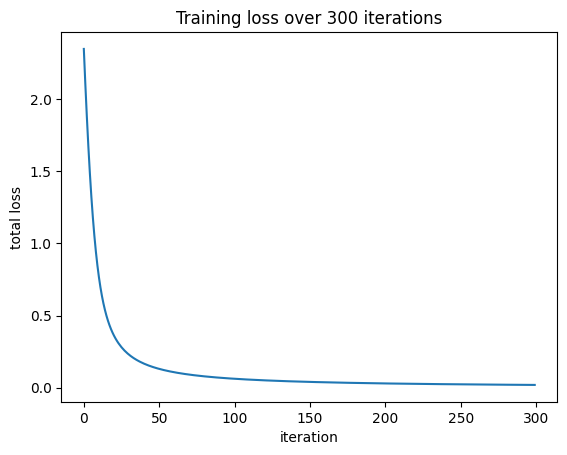

In [184]:
plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('total loss')
plt.title('Training loss over 300 iterations')
plt.show()

**PYTORCH**

In [185]:
import torch

x_t = torch.tensor(datapoint, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

W1_t = torch.tensor(weights, dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor(bias, dtype=torch.float32, requires_grad=True)
W2_t = torch.tensor(w2, dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor(b2, dtype=torch.float32, requires_grad=True)

In [186]:
z1 = W1_t @ x_t + b1_t
a1 = torch.sigmoid(z1)
z2 = W2_t @ a1 + b2_t
a2 = torch.sigmoid(z2)

loss_fn = torch.nn.BCELoss(reduction='sum')
loss = loss_fn(a2, y_t)

loss.backward()
print(W2_t.grad)

tensor([[-0.1107, -0.1175, -0.1176, -0.1103],
        [ 0.6134,  0.6511,  0.6514,  0.6111]])


In [187]:
optimizer = torch.optim.SGD([W1_t, b1_t, W2_t, b2_t], lr=0.1)

In [188]:
for i in range(300):
    optimizer.zero_grad()  # the accumulation fix — reset grads before this iteration

    z1 = W1_t @ x_t + b1_t
    a1 = torch.sigmoid(z1)
    z2 = W2_t @ a1 + b2_t
    a2 = torch.sigmoid(z2)

    loss = loss_fn(a2, y_t)
    loss.backward()
    optimizer.step() # applies w_new = w_old - lr*gradient to all 4 tensors at once

print(loss.item())

0.019020097330212593
